<a href="https://colab.research.google.com/github/IshiPareek/mech_interpet/blob/main/05_gpt2_sparse_dictionary_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1 — imports
!pip install transformer_lens
import transformer_lens
from transformer_lens import HookedTransformer, utils
from transformer_lens.hook_points import HookPoint
import torch
import numpy as np
from jaxtyping import Float, Int
import einops

print(f"TransformerLens installd")
print(f"CUDA available: {torch.cuda.is_available()}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.7/963.7 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 4.3 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=8432e9e9d33ec5136ed6a8c265ef150534b4f3097c8228fb7395e20a25225f6c
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator
TransformerLens installd
CUDA available: False


/tmp/ipykernel_23022/917394093.py:4: DeprecationWarning: The 'utils' module has been deprecated. Please use 'transformer_lens.utilities' instead. Importing from utils.py will be removed in TransformerLens 4.0.
  from transformer_lens import HookedTransformer, utils


In [ ]:
model = HookedTransformer.from_pretrained("gpt2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer


In [ ]:
token1 = model.to_tokens("The meaning of life is")
str_tokens = model.to_str_tokens(token1)
print(model.to_str_tokens(token1))
logits = model(token1)
print(logits.shape)

token2 = model.to_tokens("The capital of France is ")
str_tokens = model.to_str_tokens(token2)
print(model.to_str_tokens(token2))
logits = model(token2)
print(logits.shape)

['<|endoftext|>', 'The', ' meaning', ' of', ' life', ' is']
torch.Size([1, 6, 50257])
['<|endoftext|>', 'The', ' capital', ' of', ' France', ' is', ' ']
torch.Size([1, 7, 50257])


In [ ]:
# ── generate some text to run through the model ───────────────────────────
import tqdm.auto as tqdm

prompts = [
    "The capital of France is Paris and the capital of Germany is",
    "When Mary and John went to the store, John gave a drink to",
    "The meaning of life is to find your own path and",
    "In the beginning of the universe there was nothing but",
    "The quick brown fox jumps over the lazy dog and",
    "Machine learning models are trained on large datasets to",
    "The president of the United States lives in the White House and",
    "Python is a programming language that is widely used for",
    "The theory of relativity was proposed by Albert Einstein in",
    "Neural networks are inspired by the structure of the human",
]

# ── collect residual stream activations at layer 7 ──────────────────────── # WHY LAYER 7?
activation_store = []

def store_activations_hook(value, hook):
    activation_store.append(value.detach().cpu())

with torch.no_grad():
    for prompt in tqdm.tqdm(prompts):
        tokens = model.to_tokens(prompt)
        model.run_with_hooks(
            tokens,
            fwd_hooks=[("blocks.7.hook_resid_post", store_activations_hook)],
            return_type=None
        )

# ── stack into one big tensor ─────────────────────────────────────────────
# each activation is (1, seq_len, 768) → flatten to (n_tokens, 768)
all_activations = torch.cat([a.squeeze(0) for a in activation_store], dim=0)
print(f"Collected activations shape: {all_activations.shape}")
# should be (total_tokens, 768)

  0%|          | 0/10 [00:00<?, ?it/s]

Collected activations shape: torch.Size([119, 768])


In [ ]:
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, n_features, l1_coeff=1e-3):
        super().__init__()
        self.input_dim = input_dim      # 768 for GPT-2
        self.n_features = n_features    # how many dictionary features to learn
        self.l1_coeff = l1_coeff        # sparsity penalty strength : WHAT DOES THIS MEAN?

        # encoder: 768 → n_features
        self.W_enc = nn.Linear(input_dim, n_features, bias=True)

        # decoder: n_features → 768
        self.W_dec = nn.Linear(n_features, input_dim, bias=True)

        # normalize decoder columns to unit norm at init
        with torch.no_grad():
            self.W_dec.weight.data = nn.functional.normalize(
                self.W_dec.weight.data, dim=0
            )

    def forward(self, x):
        # encode
        features = torch.relu(self.W_enc(x))     # (batch, n_features) sparse

        # decode
        reconstructed = self.W_dec(features)      # (batch, 768)

        # losses
        reconstruction_loss = (x - reconstructed).pow(2).mean()
        sparsity_loss = self.l1_coeff * features.abs().mean()
        loss = reconstruction_loss + sparsity_loss

        return loss, reconstructed, features

# instantiate
input_dim  = 768
n_features = 768 * 4   # 4x overcomplete dictionary = 3072 features
sae = SparseAutoencoder(input_dim, n_features, l1_coeff=1e-3).to(device)

print(f"SAE parameters: {sum(p.numel() for p in sae.parameters()):,}")
print(f"Input dim:  {input_dim}")
print(f"n_features: {n_features}")

Using device: cpu
SAE parameters: 4,722,432
Input dim:  768
n_features: 3072


  0%|          | 0/200 [00:00<?, ?it/s]

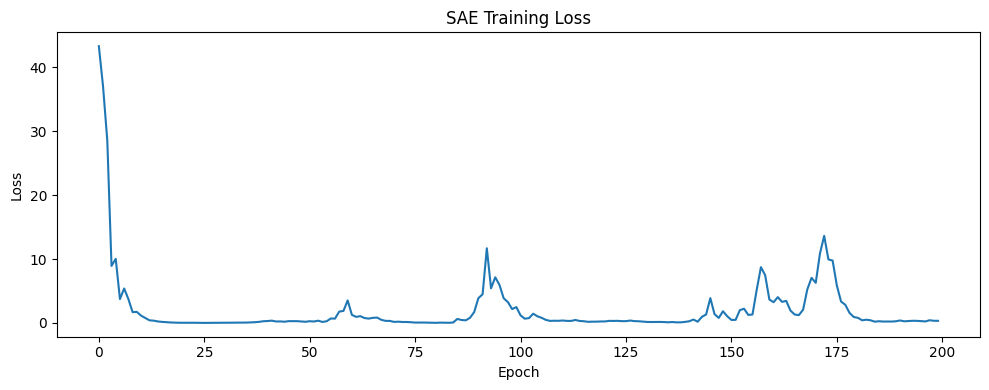

Final loss: 0.3371


In [ ]:
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import matplotlib.pyplot as plt

# ── dataloader ────────────────────────────────────────────────────────────
activations_device = all_activations.to(device)
dataset    = TensorDataset(activations_device)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# ── optimizer ─────────────────────────────────────────────────────────────
optimizer = optim.Adam(sae.parameters(), lr=1e-3)

# ── train ─────────────────────────────────────────────────────────────────
n_epochs = 200
losses   = []

for epoch in tqdm.tqdm(range(n_epochs)):
    epoch_loss = 0
    for (batch,) in dataloader:
        optimizer.zero_grad()
        loss, reconstructed, features = sae(batch)
        loss.backward()

        # normalize decoder columns after each step
        # keeps dictionary vectors unit norm
        with torch.no_grad():
            sae.W_dec.weight.data = nn.functional.normalize(
                sae.W_dec.weight.data, dim=0
            )

        optimizer.step()
        epoch_loss += loss.item()

    losses.append(epoch_loss / len(dataloader))

# ── plot training loss ────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SAE Training Loss")
plt.tight_layout()
plt.show()

print(f"Final loss: {losses[-1]:.4f}")

In [ ]:
# ── get features for all tokens ───────────────────────────────────────────
sae.eval()
with torch.no_grad():
    loss, reconstructed, features = sae(activations_device)

# features shape: (119, 3072)
print(f"Features shape: {features.shape}")
print(f"Average active features per token: {(features > 0).float().mean(1).mean().item() * 3072:.1f}")
print(f"Sparsity: {(features == 0).float().mean().item() * 100:.1f}% zeros")

# ── find most interesting features ───────────────────────────────────────
# which features activate most strongly across all tokens?
feature_activation_mean = features.mean(0)   # (3072,)
feature_activation_max  = features.max(0).values  # (3072,)

# top 10 most active features
top_features = feature_activation_max.argsort(descending=True)[:10]
print(f"\nTop 10 most active feature indices: {top_features.tolist()}")

Features shape: torch.Size([119, 3072])
Average active features per token: 379.3
Sparsity: 87.7% zeros

Top 10 most active feature indices: [2458, 2491, 2924, 2632, 769, 75, 2776, 444, 294, 556]


Tokens after stripping endoftext: 109
Features shape after stripping: torch.Size([109, 3072])


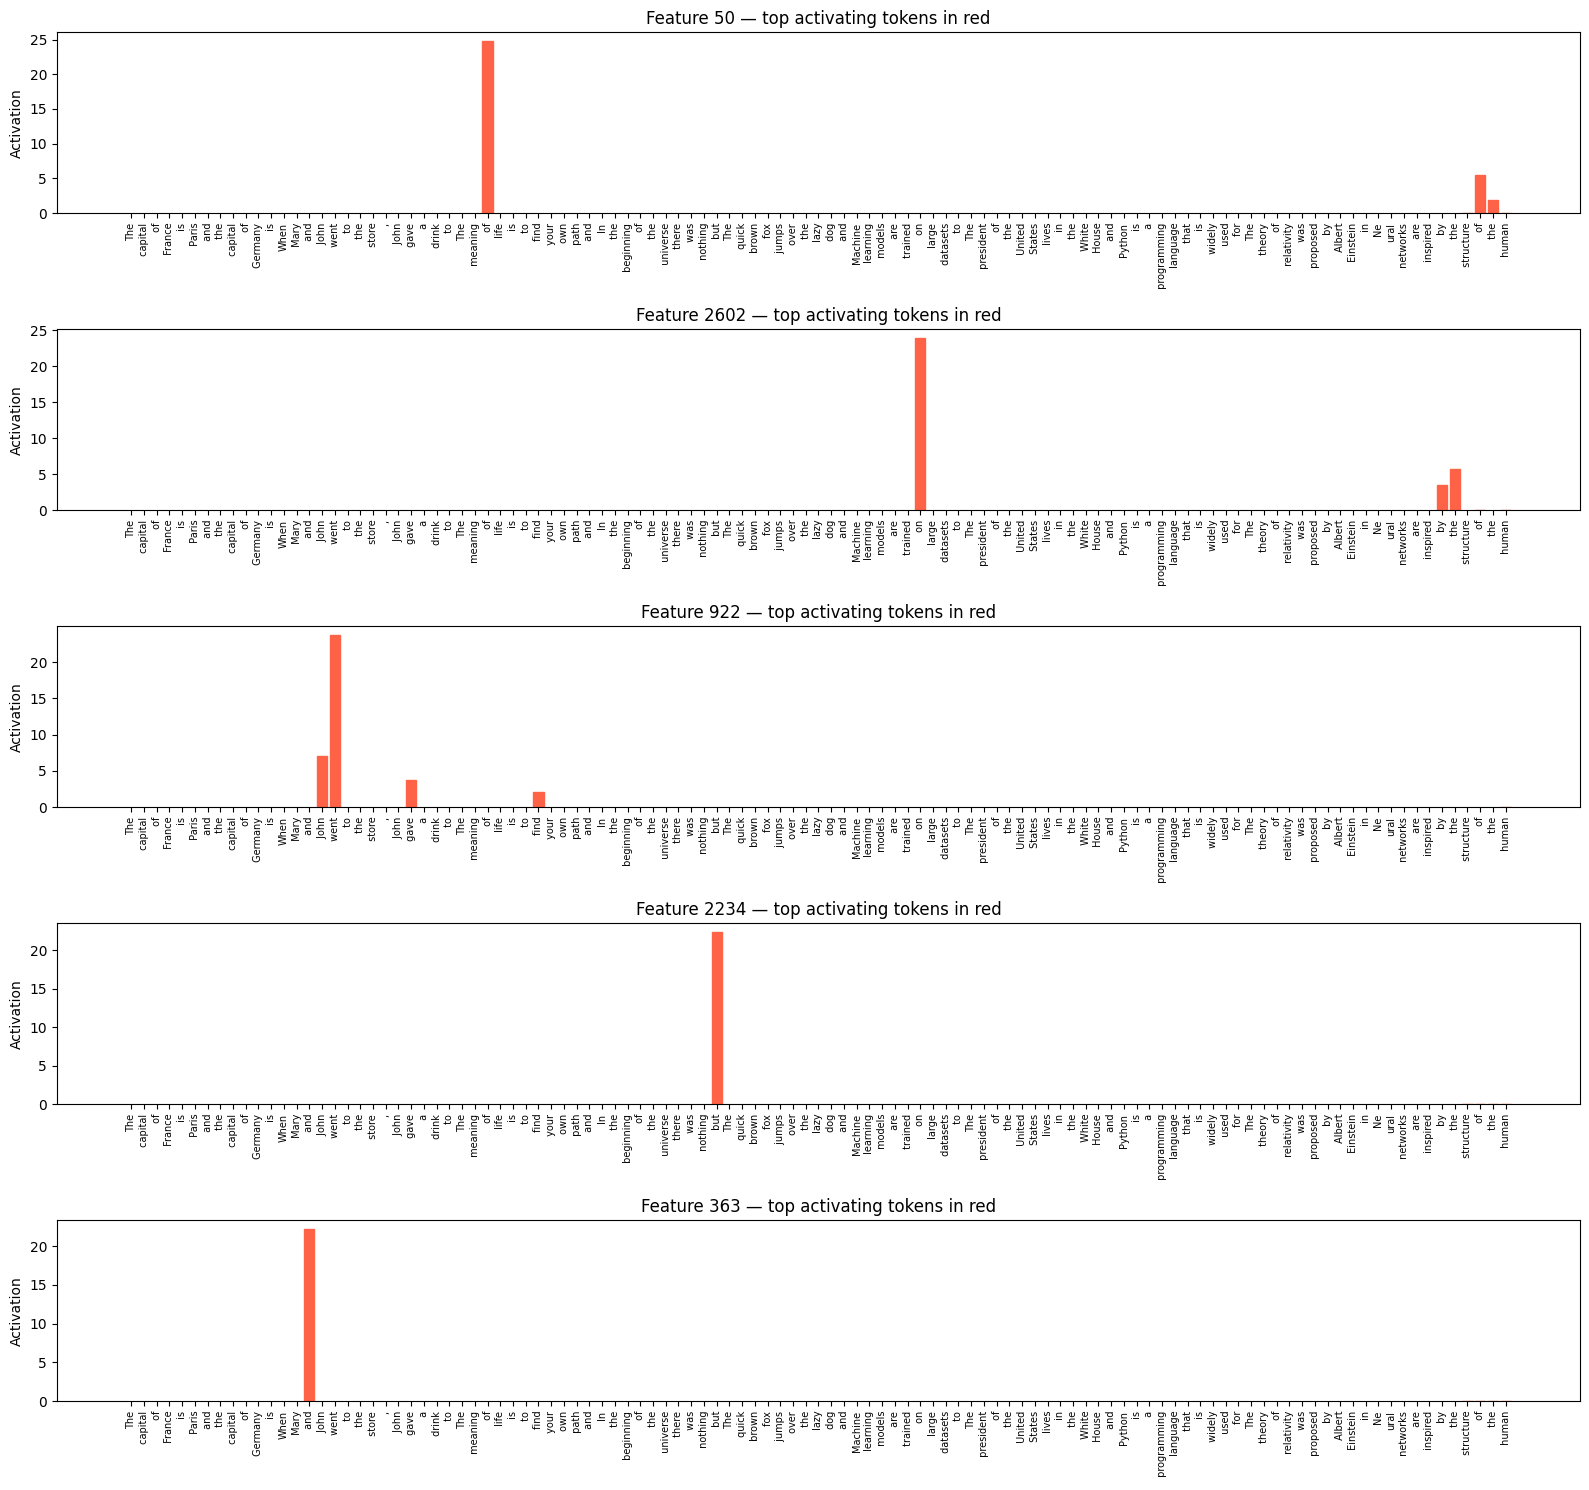

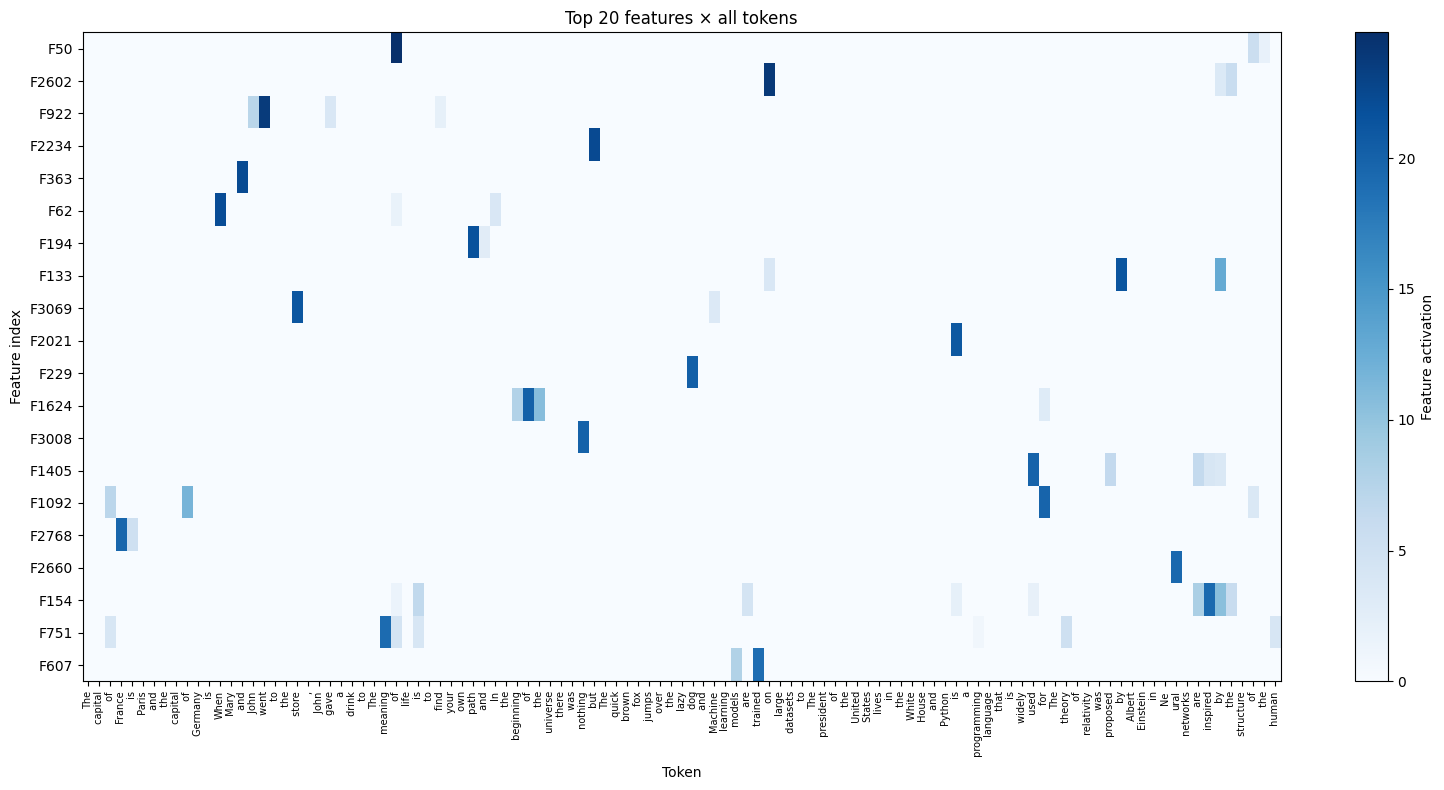

In [ ]:
# collect all tokens and their strings
all_token_strings = []
for prompt in prompts:
    str_tokens = model.to_str_tokens(prompt)
    all_token_strings.extend(str_tokens[1:])  # skip first <|endoftext|> token

# strip corresponding activations
keep_indices = []
pos = 0
for prompt in prompts:
    n_tokens = len(model.to_tokens(prompt)[0])
    keep_indices.extend(range(pos + 1, pos + n_tokens))  # skip pos 0
    pos += n_tokens

features_clean = features[keep_indices]
print(f"Tokens after stripping endoftext: {len(all_token_strings)}")
print(f"Features shape after stripping: {features_clean.shape}")

# recalculate top features from features_clean not original features
feature_activation_max_clean = features_clean.max(0).values
top_features_clean = feature_activation_max_clean.argsort(descending=True)[:20]
top_feature_indices = top_features_clean.tolist()

# ── plot top 5 features ───────────────────────────────────────────────────
n_top = 5
fig, axes = plt.subplots(n_top, 1, figsize=(16, n_top * 3))

for i, feat_idx in enumerate(top_features_clean[:n_top]):
    feat_idx = feat_idx.item()
    activations_for_feature = features_clean[:, feat_idx].cpu().numpy()  # ✅ features_clean

    ax = axes[i]
    bars = ax.bar(range(len(all_token_strings)), activations_for_feature, color="steelblue")

    # highlight top activating tokens
    top_token_idx = activations_for_feature.argsort()[-5:]
    for idx in top_token_idx:
        bars[idx].set_color("tomato")

    ax.set_xticks(range(len(all_token_strings)))
    ax.set_xticklabels(all_token_strings, rotation=90, fontsize=7)
    ax.set_title(f"Feature {feat_idx} — top activating tokens in red")
    ax.set_ylabel("Activation")

plt.tight_layout()
plt.show()

# ── heatmap ───────────────────────────────────────────────────────────────
feature_matrix = features_clean[:, top_feature_indices].cpu().numpy()  # ✅ features_clean

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(feature_matrix.T, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax, label="Feature activation")
ax.set_xlabel("Token")
ax.set_ylabel("Feature index")
ax.set_title("Top 20 features × all tokens")
ax.set_xticks(range(len(all_token_strings)))
ax.set_xticklabels(all_token_strings, rotation=90, fontsize=7)
ax.set_yticks(range(len(top_feature_indices)))
ax.set_yticklabels([f"F{i}" for i in top_feature_indices])
plt.tight_layout()
plt.show()

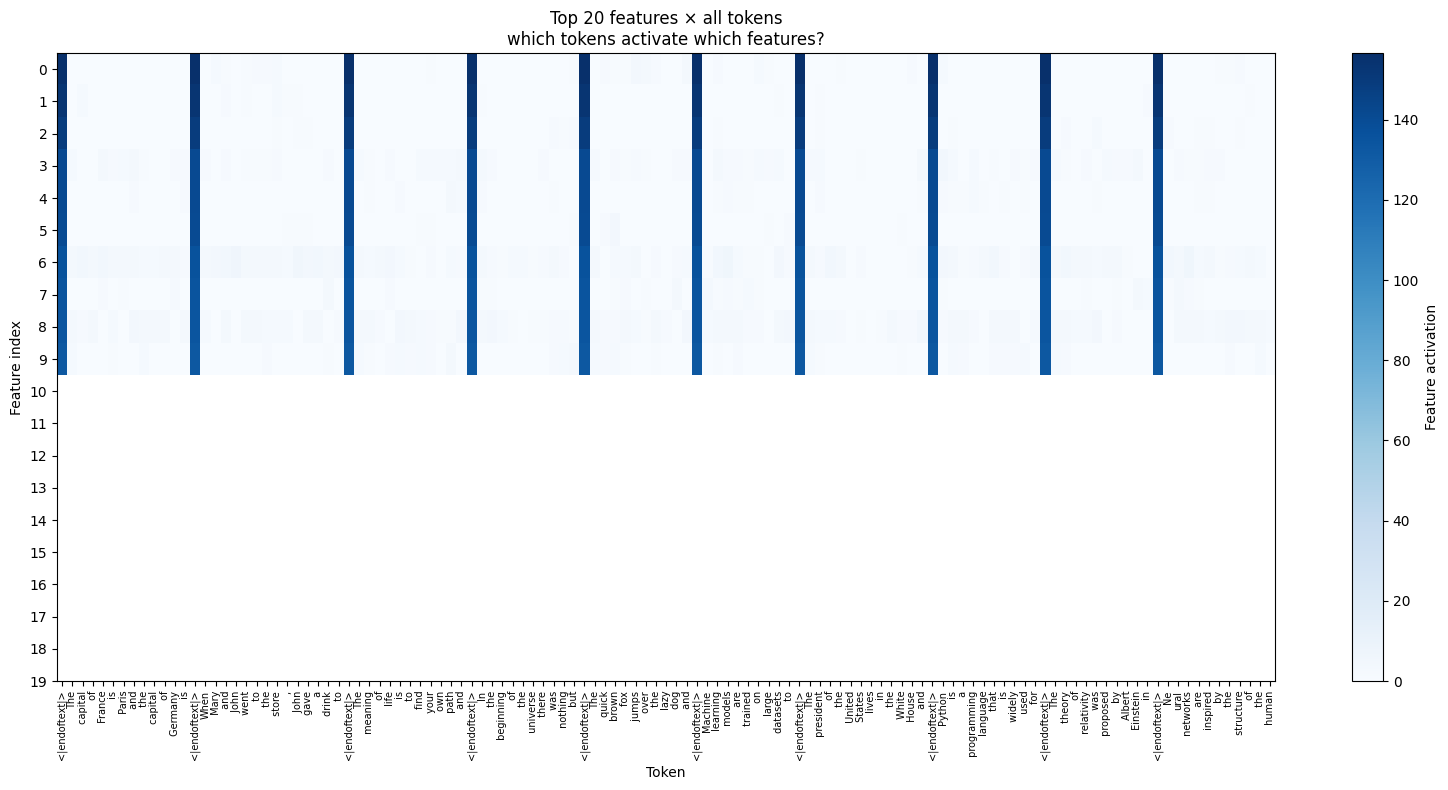

In [ ]:
# ── heatmap: tokens x top features ───────────────────────────────────────
top_n = 20
top_features = feature_activation_max.argsort(descending=True)[:20]  # change 10 to 20
top_feature_indices = top_features.tolist()

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(feature_matrix.T, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax, label="Feature activation")
ax.set_xlabel("Token")
ax.set_ylabel("Feature index")
ax.set_title("Top 20 features × all tokens\nwhich tokens activate which features?")
ax.set_xticks(range(len(all_token_strings)))
ax.set_xticklabels(all_token_strings, rotation=90, fontsize=7)
ax.set_yticks(range(top_n))
ax.set_yticks(range(len(top_feature_indices)))  # ✅ instead of range(top_n)
plt.tight_layout()
plt.show()